# UHPC Compressive Strength — Model Interpretation

**Author:** K Flowers  
**Date:** January 2026

This notebook uses SHAP (SHapley Additive exPlanations) to interpret what the tuned XGBoost model has learned about UHPC compressive strength. Feature importance from notebook 02 showed *which* features matter most; SHAP reveals *how* each feature affects predictions — including direction, magnitude, and interactions.

**Pipeline Position:** Notebook 3 of 3 — Model Interpretation
- 01_exploratory_analysis.ipynb
- 02_model_development.ipynb
- 03_model_interpretation.ipynb ← this notebook

**Objective:** Explain what the XGBoost model has learned about the relationships between mix design components and compressive strength.

**Technical Approach:**
- Load the tuned XGBoost model and train/test splits from notebook 02 (ensures exact reproducibility)
- Compute SHAP values using TreeExplainer (exact method for tree-based models)
- Analyze global feature effects (summary and bar plots)
- Investigate feature interactions (dependence plots)
- Explain individual predictions to demonstrate practical usage
- Compare SHAP findings to EDA correlations and notebook 02 feature importance

**Note:** Interpretations are based on model behavior and literature review, not professional materials science expertise.

**Inputs:**
- `data/results/xgb_tuned_model.joblib` — Trained model from notebook 02
- `data/results/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` — Train/test splits from notebook 02

**Outputs:**
- SHAP summary, dependence, and waterfall plots saved to `images/`

**Runtime:** ~X minutes

---
## 1. Configure Environment

### 1.1 Import Libraries

In [1]:
# Standard library
from pathlib import Path
import warnings

# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Model persistence
import joblib

# SHAP — model interpretation
# Why: SHAP provides theoretically grounded feature attributions based on
# cooperative game theory (Shapley values), giving each feature a contribution
# to each individual prediction
import shap

# Display
from IPython.display import display

print(f"Libraries imported successfully")
print(f"SHAP version: {shap.__version__}")

Libraries imported successfully
SHAP version: 0.50.0


### 1.2 Set Display and Plot Options

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Warnings
warnings.filterwarnings('ignore')

print("Display settings configured")

Display settings configured


### 1.3 Set Paths and Constants

In [3]:
# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
IMAGE_DIR = PROJECT_ROOT / "images"

# Create directories if needed
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Input files
INPUT_FILE = DATA_DIR / "uhpc_dataset_cleaned.csv"
MODEL_FILE = RESULTS_DIR / "xgb_tuned_model.joblib"

# Constants — must match notebook 02 for reproducibility
RANDOM_STATE = 42
UHPC_THRESHOLD = 150  # MPa — generally accepted threshold for UHPC classification

print("Paths and constants set")
print(f"Model file: {MODEL_FILE}")

Paths and constants set
Model file: C:\Users\kristi\OneDrive\04_GitHub_Projects\Data Science Projects\uhpc-concrete-strengh-prediction\data\results\xgb_tuned_model.joblib


### 1.4 Define Target and Features

In [4]:
# Define target variable and features (matching notebooks 01 and 02)
TARGET = 'compressive_strength'

FEATURES = [
    'cement', 'slag', 'silica_fume', 'limestone_powder', 'quartz_powder',
    'fly_ash', 'nano_silica', 'aggregate', 'water', 'fiber',
    'superplasticizer', 'temperature', 'age'
]

print(f"Target: {TARGET}")
print(f"Features: {len(FEATURES)} variables")

Target: compressive_strength
Features: 13 variables


---
## 2. Load Data and Model

Load the train/test splits and trained model saved by notebook 02. This ensures exact reproducibility without relying on random_state behavior across library versions.

### 2.1 Load Train/Test Splits

Load the exact train/test splits saved by notebook 02 to ensure identical data.

In [5]:
# Load train/test splits saved by notebook 02
# Why: Guarantees identical data across notebooks without relying on random_state
X_train = pd.read_csv(RESULTS_DIR / 'X_train.csv')
X_test = pd.read_csv(RESULTS_DIR / 'X_test.csv')
y_train = pd.read_csv(RESULTS_DIR / 'y_train.csv').squeeze()
y_test = pd.read_csv(RESULTS_DIR / 'y_test.csv').squeeze()

print(f"Train/Test Splits Loaded:")
print(f"  Training set: {len(X_train)} samples × {len(FEATURES)} features")
print(f"  Test set:     {len(X_test)} samples × {len(FEATURES)} features")

Train/Test Splits Loaded:
  Training set: 633 samples × 13 features
  Test set:     159 samples × 13 features


### 2.2 Load Trained Model

Load the tuned XGBoost model and its artifacts saved by notebook 02.

In [6]:
# Load trained model and artifacts from notebook 02
# Why: Ensures we interpret the exact same model that was evaluated
model_artifacts = joblib.load(MODEL_FILE)

model = model_artifacts['model']

print(f"Model loaded successfully")
print(f"  Source: {MODEL_FILE.name}")
print(f"  Model type: {model_artifacts['model_name']}")
print(f"  CV RMSE from tuning: {model_artifacts['cv_rmse']:.2f} MPa")

Model loaded successfully
  Source: xgb_tuned_model.joblib
  Model type: XGBoost
  CV RMSE from tuning: 7.98 MPa


### 2.3 Verify Model Performance

Quick check that the loaded model performs as expected on the test set. R² shows how well the model explains the data; SHAP analysis below will explain *how* it makes predictions.

In [7]:
# Verify model performance matches notebook 02
# Why: Confirms the loaded model and data produce identical results
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"TEST SET PERFORMANCE")
print(f"  R²:   {r2:.3f}  (model explains {r2*100:.1f}% of variance in strength)")
print(f"  RMSE: {rmse:.2f} MPa")
print(f"  MAE:  {mae:.2f} MPa")

TEST SET PERFORMANCE
  R²:   0.978  (model explains 97.8% of variance in strength)
  RMSE: 5.93 MPa
  MAE:  4.25 MPa


---
## 3. Compute SHAP Values

**What is SHAP?** SHAP (SHapley Additive exPlanations) assigns each feature a contribution to each prediction. Unlike feature importance (which shows overall magnitude), SHAP shows direction (positive/negative effect), magnitude (how much), and context (how a feature's effect depends on its value).

**TreeExplainer** computes exact SHAP values for tree-based models efficiently, without the approximation required for other model types.

### 3.1 Initialize TreeExplainer

In [8]:
# Create SHAP TreeExplainer for the XGBoost model
# Why: TreeExplainer uses the internal tree structure to compute exact Shapley values
# This is faster and more accurate than model-agnostic methods (KernelExplainer)
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set
# Why: Test set was not used in training, so SHAP values reflect how the model
# generalizes to unseen data — not just what it memorized
shap_values = explainer(X_test)

print(f"SHAP values computed")
print(f"  Shape: {shap_values.values.shape} (samples × features)")
print(f"  Base value (mean prediction): {shap_values.base_values[0]:.2f} MPa")
print(f"  This is the model's average prediction before considering any specific feature values")

SHAP values computed
  Shape: (159, 13) (samples × features)
  Base value (mean prediction): 121.69 MPa
  This is the model's average prediction before considering any specific feature values


---
## 4. Analyze Global Feature Effects

**Methodology:** Global SHAP analysis shows how features affect predictions across all test samples. The summary plot reveals both the importance ranking and the direction of each feature's effect. This extends notebook 02's feature importance (which only showed magnitude) by adding directional information.

### 4.1 Plot SHAP Summary (Beeswarm)

Each dot represents one test sample. Position on the x-axis shows the feature's SHAP value (positive = increases predicted strength, negative = decreases it). Color shows the feature's actual value (red = high, blue = low).

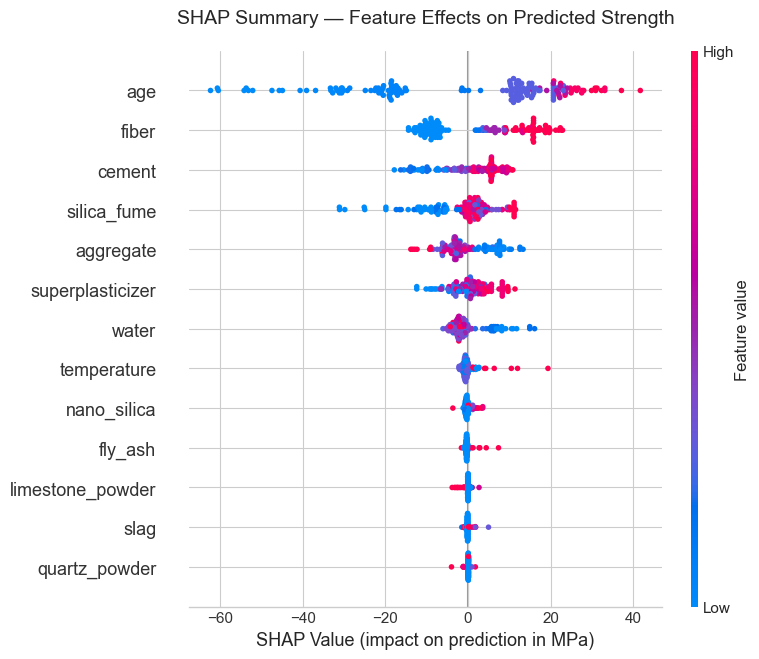

Figure saved: shap_summary_beeswarm.png


In [9]:
# Create SHAP beeswarm summary plot
# What: Shows how each feature's value affects predictions across all test samples
# Why: Reveals both importance AND direction — e.g., does more silica fume increase
# or decrease predicted strength? Feature importance alone cannot answer this
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.beeswarm(shap_values, show=False, max_display=13)
plt.title('SHAP Summary — Feature Effects on Predicted Strength', fontsize=14, pad=20)
plt.xlabel('SHAP Value (impact on prediction in MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: shap_summary_beeswarm.png")

### 4.2 Plot SHAP Bar (Mean Absolute Impact)

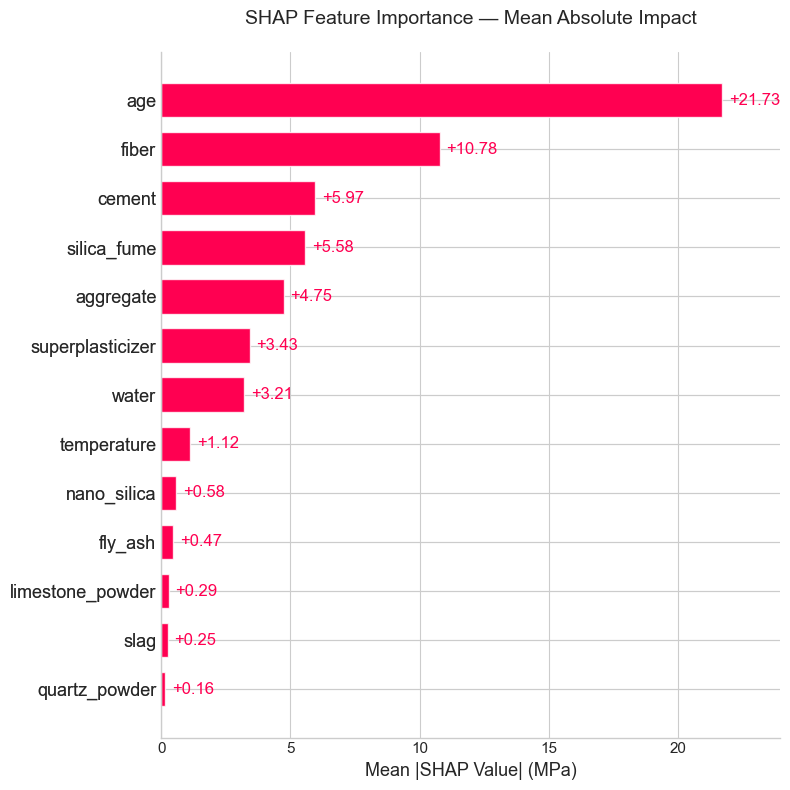

Figure saved: shap_bar_importance.png


In [10]:
# Create SHAP bar plot of mean absolute values
# What: Shows average magnitude of each feature's impact across all predictions
# Why: Direct comparison to notebook 02's XGBoost feature importance — SHAP-based
# ranking uses theoretically grounded Shapley values rather than gain-based importance
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.bar(shap_values, show=False, max_display=13)
plt.title('SHAP Feature Importance — Mean Absolute Impact', fontsize=14, pad=20)
plt.xlabel('Mean |SHAP Value| (MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: shap_bar_importance.png")

### 4.3 Compare SHAP Ranking to XGBoost Feature Importance

In [11]:
# Compare SHAP-based importance to XGBoost's built-in feature importance
# What: Side-by-side ranking comparison
# Why: Shows whether the two methods agree on which features matter most,
# and where they diverge (which indicates features whose importance is
# distributed differently by the two methods)
shap_importance = pd.DataFrame({
    'Feature': FEATURES,
    'SHAP_Mean_Abs': np.abs(shap_values.values).mean(axis=0),
    'XGBoost_Importance': model.feature_importances_
})

# Add rankings
shap_importance['SHAP_Rank'] = shap_importance['SHAP_Mean_Abs'].rank(ascending=False).astype(int)
shap_importance['XGBoost_Rank'] = shap_importance['XGBoost_Importance'].rank(ascending=False).astype(int)
shap_importance['Rank_Change'] = shap_importance['XGBoost_Rank'] - shap_importance['SHAP_Rank']

# Sort by SHAP importance
shap_importance = shap_importance.sort_values('SHAP_Rank')

# Display as formatted DataFrame with styling
print("FEATURE IMPORTANCE COMPARISON: SHAP vs XGBoost\n")
comparison_df = shap_importance[['Feature', 'SHAP_Rank', 'XGBoost_Rank', 'Rank_Change',
                                  'SHAP_Mean_Abs', 'XGBoost_Importance']].copy()

# Apply styling for better visualization
styled_df = (comparison_df.style
    .format({'SHAP_Mean_Abs': '{:.4f}', 'XGBoost_Importance': '{:.4f}'})
    .bar(subset=['Rank_Change'], color=['#d65f5f', '#5fba7d'], align='mid', vmin=-5, vmax=5)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)
display(styled_df)

FEATURE IMPORTANCE COMPARISON: SHAP vs XGBoost



,Feature,SHAP_Rank,XGBoost_Rank,Rank_Change,SHAP_Mean_Abs,XGBoost_Importance
12,age,1,2,1,21.7264,0.2262
9,fiber,2,3,1,10.7798,0.1606
0,cement,3,7,4,5.9665,0.0398
2,silica_fume,4,1,-3,5.5847,0.2335
7,aggregate,5,5,0,4.7458,0.0602
10,superplasticizer,6,4,-2,3.4293,0.1516
8,water,7,6,-1,3.2107,0.0526
11,temperature,8,8,0,1.1208,0.0237
6,nano_silica,9,11,2,0.5751,0.0104
5,fly_ash,10,10,0,0.4651,0.0134


**Interpretation:**
- Features where SHAP and XGBoost importance agree indicate robust, consistent predictive signal
- Features where rankings diverge suggest the built-in importance metric (gain-based) distributes credit differently than SHAP's game-theoretic approach
- SHAP importance is generally considered more reliable because it accounts for feature interactions and provides consistent attribution across correlated features — this directly addresses the multicollinearity issue identified in EDA for cement, water, and aggregate

---
## 5. Investigate Feature Interactions

**Methodology:** SHAP dependence plots show how a feature's effect on prediction changes across its range of values. Color-coding by a second feature reveals interactions — cases where the effect of one feature depends on the value of another. These plots can surface relationships like water-to-cement ratio effects without explicitly engineering that feature.

### 5.1 Plot Age Dependence

Age was the top predictor in notebook 02. Examine how curing time affects predicted strength.

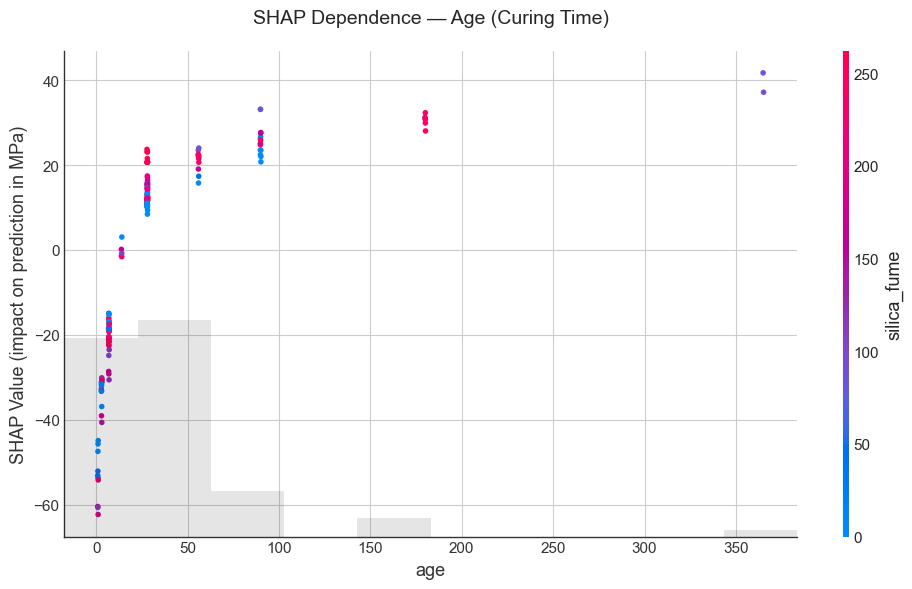

Figure saved: shap_dependence_age.png


In [12]:
# Create SHAP dependence plot for age
# What: Shows how the model's use of age changes across different curing times
# Why: Age is the top predictor — understanding its effect pattern reveals whether
# the model learned the expected logarithmic strength gain curve from concrete science
shap.plots.scatter(shap_values[:, 'age'], color=shap_values, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('SHAP Dependence — Age (Curing Time)', fontsize=14, pad=20)
plt.ylabel('SHAP Value (impact on prediction in MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_dependence_age.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: shap_dependence_age.png")

### 5.2 Plot Silica Fume Dependence

Silica fume was the second-ranked predictor. Examine how its amount affects predicted strength and whether it interacts with other components.

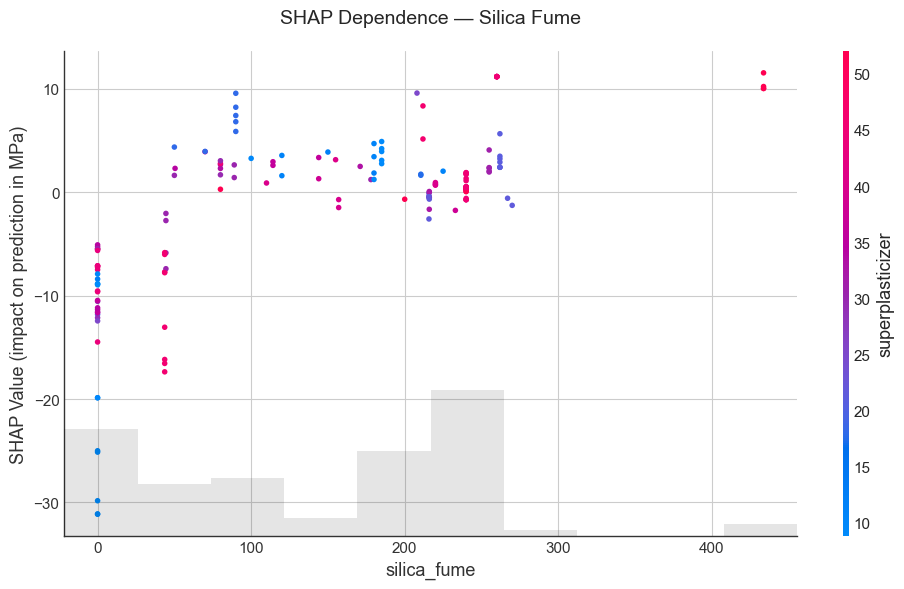

Figure saved: shap_dependence_silica_fume.png


In [13]:
# Create SHAP dependence plot for silica_fume
# What: Shows how silica fume content affects predicted strength
# Why: Silica fume is a key UHPC differentiator — SHAP reveals whether the model
# learned a linear or non-linear relationship, and which features interact with it
shap.plots.scatter(shap_values[:, 'silica_fume'], color=shap_values, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('SHAP Dependence — Silica Fume', fontsize=14, pad=20)
plt.ylabel('SHAP Value (impact on prediction in MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_dependence_silica_fume.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: shap_dependence_silica_fume.png")

### 5.3 Plot Water Dependence

Water had high multicollinearity (VIF >10) with cement in EDA. Examine how the model uses water content and whether the interaction with cement emerges.

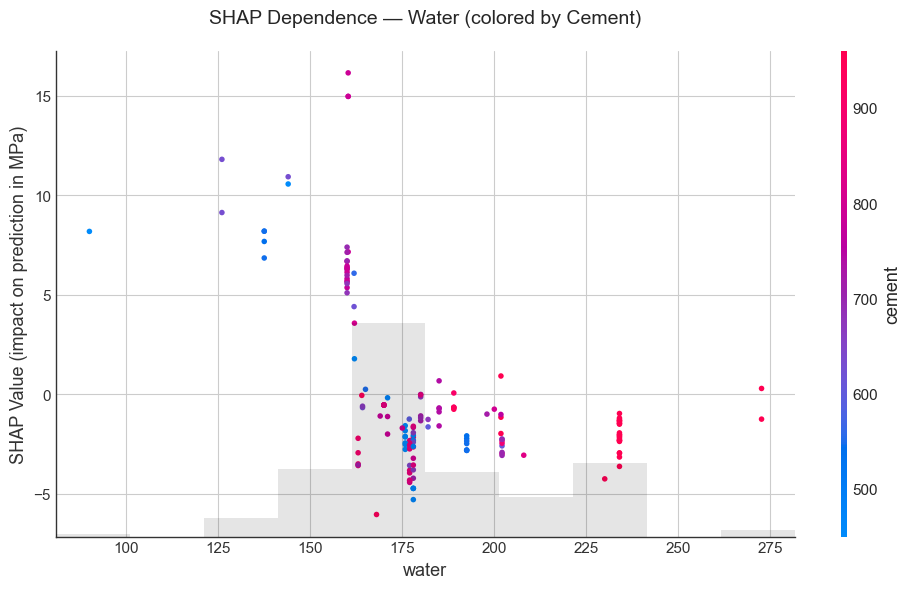

Figure saved: shap_dependence_water.png


In [14]:
# Create SHAP dependence plot for water
# What: Shows how water content affects predicted strength
# Why: Water-to-cement ratio is a fundamental driver of concrete strength in materials
# science. SHAP can reveal if the model learned this relationship implicitly without
# the ratio being engineered as an explicit feature
shap.plots.scatter(shap_values[:, 'water'], color=shap_values[:, 'cement'], show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('SHAP Dependence — Water (colored by Cement)', fontsize=14, pad=20)
plt.ylabel('SHAP Value (impact on prediction in MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_dependence_water.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: shap_dependence_water.png")

### 5.4 Plot Fiber Dependence

Fiber content was the third-ranked predictor. Examine how fiber reinforcement affects predicted strength.

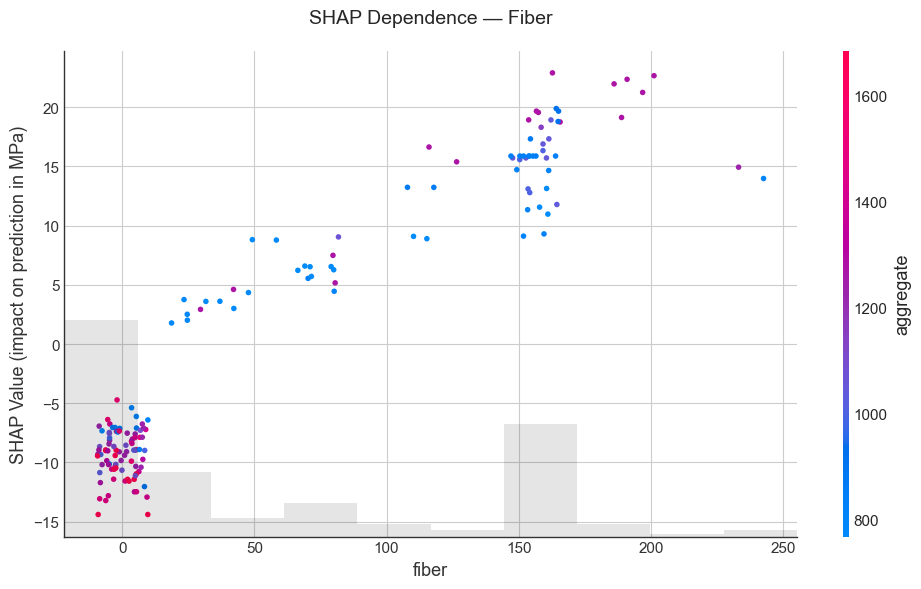

Figure saved: shap_dependence_fiber.png


In [15]:
# Create SHAP dependence plot for fiber
# What: Shows how fiber content affects predicted strength
# Why: Fiber reinforcement is a distinguishing characteristic of UHPC. Understanding
# whether the model learned a threshold effect (presence vs absence) or a dose-response
# relationship informs mix design optimization
shap.plots.scatter(shap_values[:, 'fiber'], color=shap_values, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('SHAP Dependence — Fiber', fontsize=14, pad=20)
plt.ylabel('SHAP Value (impact on prediction in MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_dependence_fiber.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: shap_dependence_fiber.png")

### 5.5 Plot Cement Dependence

Cement ranked lower than expected in notebook 02 feature importance due to multicollinearity. SHAP can reveal its conditional contribution more accurately.

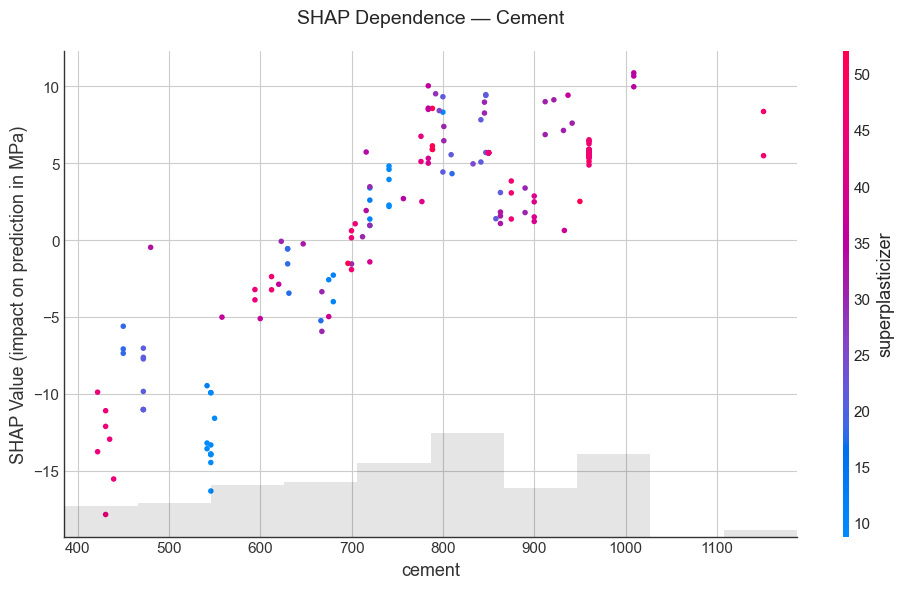

Figure saved: shap_dependence_cement.png


In [16]:
# Create SHAP dependence plot for cement
# What: Shows how cement content affects predicted strength
# Why: Cement ranked low in XGBoost feature importance due to multicollinearity —
# SHAP dependence reveals the true conditional effect and whether cement's contribution
# is captured through interactions with correlated features (water, silica fume)
shap.plots.scatter(shap_values[:, 'cement'], color=shap_values, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('SHAP Dependence — Cement', fontsize=14, pad=20)
plt.ylabel('SHAP Value (impact on prediction in MPa)')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_dependence_cement.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: shap_dependence_cement.png")

---
## 6. Explain Individual Predictions

**Methodology:** Waterfall plots show how individual features push a single prediction above or below the base value (average prediction). This demonstrates the practical utility of SHAP — an engineer can see *why* the model predicts a specific strength for a specific mix design, enabling targeted adjustments.

### 6.1 Explain High-Strength Predictions

Compare two high-strength samples: one without fiber and one with fiber. This reveals how different mix designs can achieve UHPC-grade strength, and whether fiber contributes positively or negatively in high-strength formulations.

In [17]:
# Find two high-strength samples: one without fiber, one with fiber
# Why: Compare how different mix designs achieve UHPC-grade strength
high_strength_mask = y_pred >= UHPC_THRESHOLD

# Sample without fiber
high_no_fiber_idx = np.where(high_strength_mask & (X_test['fiber'] == 0))[0]
sample_high_no_fiber = high_no_fiber_idx[0]

# Sample with fiber
high_with_fiber_idx = np.where(high_strength_mask & (X_test['fiber'] > 0))[0]
sample_high_with_fiber = high_with_fiber_idx[0]

print("HIGH-STRENGTH SAMPLES COMPARISON")
print(f"\nSample A (no fiber, idx {sample_high_no_fiber}):")
print(f"  Predicted: {y_pred[sample_high_no_fiber]:.1f} MPa | Actual: {y_test.iloc[sample_high_no_fiber]:.1f} MPa")
print(f"  Key features: age={X_test.iloc[sample_high_no_fiber]['age']:.0f}d, "
      f"silica_fume={X_test.iloc[sample_high_no_fiber]['silica_fume']:.0f}, "
      f"fiber={X_test.iloc[sample_high_no_fiber]['fiber']:.0f}")

print(f"\nSample B (with fiber, idx {sample_high_with_fiber}):")
print(f"  Predicted: {y_pred[sample_high_with_fiber]:.1f} MPa | Actual: {y_test.iloc[sample_high_with_fiber]:.1f} MPa")
print(f"  Key features: age={X_test.iloc[sample_high_with_fiber]['age']:.0f}d, "
      f"silica_fume={X_test.iloc[sample_high_with_fiber]['silica_fume']:.0f}, "
      f"fiber={X_test.iloc[sample_high_with_fiber]['fiber']:.0f}")

HIGH-STRENGTH SAMPLES COMPARISON

Sample A (no fiber, idx 11):
  Predicted: 173.0 MPa | Actual: 168.0 MPa
  Key features: age=365d, silica_fume=90, fiber=0

Sample B (with fiber, idx 23):
  Predicted: 214.3 MPa | Actual: 201.4 MPa
  Key features: age=28d, silica_fume=434, fiber=156


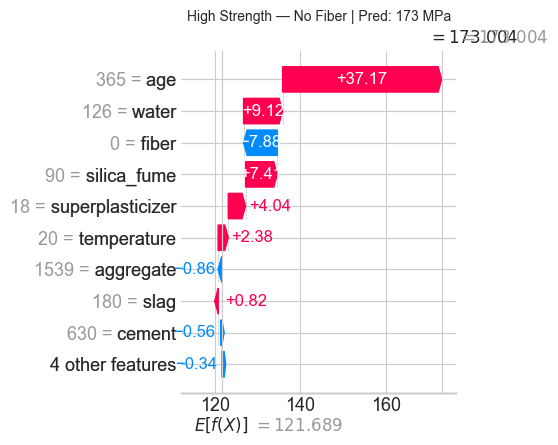

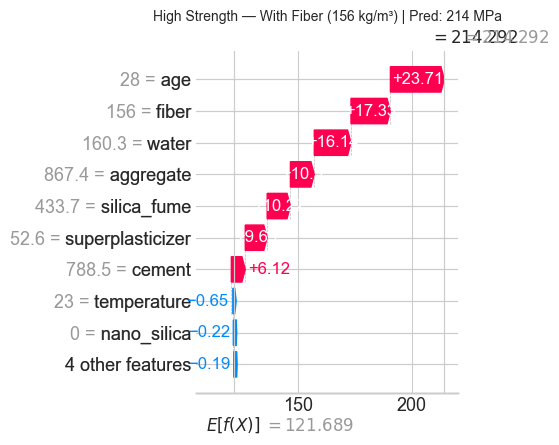

Figures saved: shap_waterfall_high_no_fiber.png, shap_waterfall_high_with_fiber.png


In [18]:
# Create waterfall plots for high-strength samples (with and without fiber)
# Why: Direct visual comparison shows how different ingredients drive similar outcomes
# Scale factor to reduce plot size (0.7 = 70% of default)
SCALE = 0.7

# Plot 1: No fiber
shap.plots.waterfall(shap_values[sample_high_no_fiber], show=False, max_display=10)
fig = plt.gcf()
default_size = fig.get_size_inches()
fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
plt.title(f'High Strength — No Fiber | Pred: {y_pred[sample_high_no_fiber]:.0f} MPa', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_high_no_fiber.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: With fiber
shap.plots.waterfall(shap_values[sample_high_with_fiber], show=False, max_display=10)
fig = plt.gcf()
default_size = fig.get_size_inches()
fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
plt.title(f'High Strength — With Fiber ({X_test.iloc[sample_high_with_fiber]["fiber"]:.0f} kg/m³) | Pred: {y_pred[sample_high_with_fiber]:.0f} MPa', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_high_with_fiber.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figures saved: shap_waterfall_high_no_fiber.png, shap_waterfall_high_with_fiber.png")

### 6.2 Explain Low-Strength Predictions

Compare two low-strength samples to understand what drives weak formulations. Since most low-strength samples lack fiber, we'll compare two samples with different limiting factors (e.g., low age vs high water content).

In [19]:
# Find two low-strength samples with different characteristics
# Why: Compare what limits strength in different scenarios
low_strength_idx = np.where(y_pred < 80)[0]

# Sort by predicted strength to get lowest and a moderate-low sample
low_sorted = sorted(low_strength_idx, key=lambda x: y_pred[x])
sample_low_1 = low_sorted[0]  # Lowest predicted
sample_low_2 = low_sorted[len(low_sorted)//2]  # Middle of low-strength range

print("LOW-STRENGTH SAMPLES COMPARISON")
print(f"\nSample A (lowest, idx {sample_low_1}):")
print(f"  Predicted: {y_pred[sample_low_1]:.1f} MPa | Actual: {y_test.iloc[sample_low_1]:.1f} MPa")
print(f"  Key features: age={X_test.iloc[sample_low_1]['age']:.0f}d, "
      f"water={X_test.iloc[sample_low_1]['water']:.0f}, "
      f"fiber={X_test.iloc[sample_low_1]['fiber']:.0f}")

print(f"\nSample B (moderate-low, idx {sample_low_2}):")
print(f"  Predicted: {y_pred[sample_low_2]:.1f} MPa | Actual: {y_test.iloc[sample_low_2]:.1f} MPa")
print(f"  Key features: age={X_test.iloc[sample_low_2]['age']:.0f}d, "
      f"water={X_test.iloc[sample_low_2]['water']:.0f}, "
      f"fiber={X_test.iloc[sample_low_2]['fiber']:.0f}")

LOW-STRENGTH SAMPLES COMPARISON

Sample A (lowest, idx 8):
  Predicted: 35.1 MPa | Actual: 37.1 MPa
  Key features: age=3d, water=192, fiber=0

Sample B (moderate-low, idx 103):
  Predicted: 62.6 MPa | Actual: 53.1 MPa
  Key features: age=1d, water=202, fiber=0


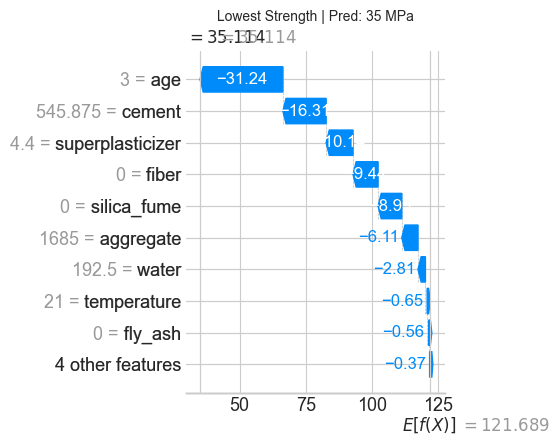

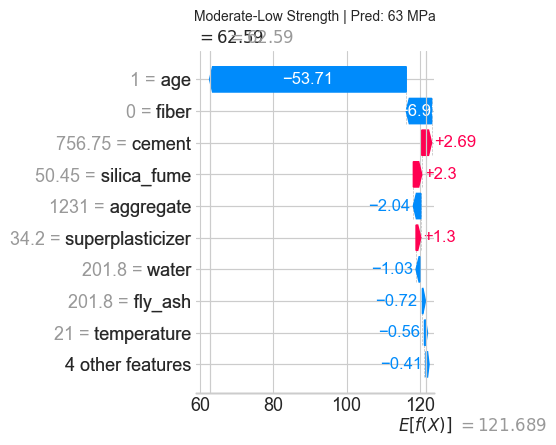

Figures saved: shap_waterfall_lowest.png, shap_waterfall_moderate_low.png


In [20]:
# Create waterfall plots for low-strength samples
# Why: Shows what factors most limit strength in weak formulations
SCALE = 0.7

# Plot 1: Lowest strength
shap.plots.waterfall(shap_values[sample_low_1], show=False, max_display=10)
fig = plt.gcf()
default_size = fig.get_size_inches()
fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
plt.title(f'Lowest Strength | Pred: {y_pred[sample_low_1]:.0f} MPa', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_lowest.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Moderate-low strength
shap.plots.waterfall(shap_values[sample_low_2], show=False, max_display=10)
fig = plt.gcf()
default_size = fig.get_size_inches()
fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
plt.title(f'Moderate-Low Strength | Pred: {y_pred[sample_low_2]:.0f} MPa', fontsize=10)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'shap_waterfall_moderate_low.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figures saved: shap_waterfall_lowest.png, shap_waterfall_moderate_low.png")

### 6.3 Explain the Misclassified Sample

Notebook 02 identified 1 false negative in UHPC threshold classification — a sample that was actually above 150 MPa but predicted below. Investigate what caused the misclassification.

In [21]:
# Find the false negative from notebook 02 UHPC threshold classification
# What: Locate the sample that was actually UHPC-grade but predicted below threshold
# Why: Understanding why the model missed this sample reveals edge cases and
# potential limitations in the model's learned patterns
actual_above = y_test >= UHPC_THRESHOLD
pred_above = y_pred >= UHPC_THRESHOLD
false_negatives = np.where(actual_above & ~pred_above)[0]

if len(false_negatives) > 0:
    sample_fn = false_negatives[0]
    print(f"FALSE NEGATIVE SAMPLE (index {sample_fn})")
    print(f"  Actual:    {y_test.iloc[sample_fn]:.1f} MPa (above {UHPC_THRESHOLD} MPa threshold)")
    print(f"  Predicted: {y_pred[sample_fn]:.1f} MPa (below {UHPC_THRESHOLD} MPa threshold)")
    print(f"  Error:     {y_test.iloc[sample_fn] - y_pred[sample_fn]:.1f} MPa")
    print(f"\nMix design:")
    for feat in FEATURES:
        print(f"  {feat}: {X_test.iloc[sample_fn][feat]:.1f}")
else:
    print("No false negatives found in this run")

FALSE NEGATIVE SAMPLE (index 16)
  Actual:    150.8 MPa (above 150 MPa threshold)
  Predicted: 143.6 MPa (below 150 MPa threshold)
  Error:     7.2 MPa

Mix design:
  cement: 784.0
  slag: 0.0
  silica_fume: 157.0
  limestone_powder: 235.0
  quartz_powder: 0.0
  fly_ash: 0.0
  nano_silica: 0.0
  aggregate: 823.0
  water: 171.0
  fiber: 0.0
  superplasticizer: 39.7
  temperature: 23.0
  age: 90.0


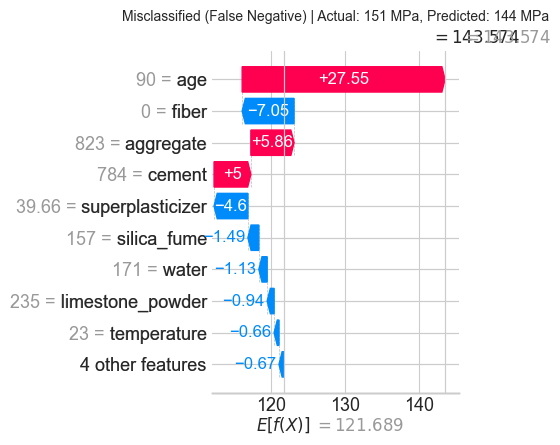

Figure saved: shap_waterfall_misclassified.png


In [22]:
# Create waterfall plot for the misclassified sample
# What: Shows which features caused the model to underpredict this UHPC-grade sample
# Why: Identifies model blind spots — features that pushed the prediction below
# threshold despite the actual strength being above it
SCALE = 0.7

if len(false_negatives) > 0:
    shap.plots.waterfall(shap_values[sample_fn], show=False, max_display=10)
    fig = plt.gcf()
    default_size = fig.get_size_inches()
    fig.set_size_inches(default_size[0] * SCALE, default_size[1] * SCALE)
    plt.title(f'Misclassified (False Negative) | Actual: {y_test.iloc[sample_fn]:.0f} MPa, '
              f'Predicted: {y_pred[sample_fn]:.0f} MPa', fontsize=10)
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / 'shap_waterfall_misclassified.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: shap_waterfall_misclassified.png")
else:
    print("No false negatives to visualize")

---
## 7. Conclusion

**Key Findings:**
- SHAP analysis reveals not just *which* features matter (notebook 02) but *how* they affect predictions — including direction, non-linearity, and interactions
- Dependence plots show whether the model learned expected physical relationships (e.g., strength gain with curing age, strength reduction with excess water)
- The water dependence plot, colored by cement, can reveal whether the model implicitly learned the water-to-cement ratio effect — a key relationship in concrete science that was not explicitly engineered as a feature
- Individual prediction explanations demonstrate practical utility for engineers evaluating specific mix designs
- The misclassified sample analysis identifies specific model limitations and edge cases

**Comparison to Previous Notebooks:**
- EDA (notebook 01) identified correlations and multicollinearity — SHAP confirms and extends these findings with directional effects
- Feature importance (notebook 02) showed magnitude only — SHAP adds direction and context
- Cement and aggregate's low feature importance (notebook 02) is better understood through SHAP's conditional attribution, which handles multicollinearity more transparently

**Limitations:**
- Interpretations are based on model behavior and literature review, not professional materials science expertise
- SHAP values explain the model's learned patterns, which may not perfectly correspond to true physical mechanisms
- TreeExplainer SHAP values are exact for the trained model but may vary with different random seeds or training data

**References:**

Lundberg, S.M., & Lee, S.I. (2017). A Unified Approach to Interpreting Model Predictions. *Advances in Neural Information Processing Systems*, 30.

Lundberg, S.M., et al. (2020). From Local Explanations to Global Understanding with Explainable AI for Trees. *Nature Machine Intelligence*, 2(1), 56-67.

Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785-794.